# Random Forest Classification — Parks Canada Wildlife Conflict Risk
### Capstone Project II

This notebook uses a **two-stage classification strategy**:

- **Stage 1 — Binary model:** Predicts HIGH RISK vs NOT HIGH RISK. This is the primary model.
  Clean class boundary, high Kappa, directly actionable for park management.

- **Stage 2 — Sub-classifier:** For incidents predicted as NOT HIGH, further classifies into LOW vs MEDIUM.
  Runs only on the subset where HIGH has already been ruled out.

**Why this approach?**
The Parks Canada dataset has 88% HIGH risk incidents. A single 3-class model can never learn
a clean LOW/MEDIUM boundary when MEDIUM is only 1.8% of the data — SMOTE and tuning cannot fix
a boundary that is genuinely ambiguous with so few real samples.
Splitting into two focused problems gives each model a fair chance to learn.

## Step 1 — Import Libraries and Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from imblearn.over_sampling import SMOTE

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/parks_canada_rf.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(df['RISK_LEVEL'].value_counts())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset: 55870 rows, 11 columns
RISK_LEVEL
HIGH      49244
LOW        5598
MEDIUM     1028
Name: count, dtype: int64


## Step 2 — Feature Engineering
We build richer features before modelling — particularly spatial density features
which tell the model how historically active each area has been.

In [ ]:
# --- Temporal features ---
def get_season(month):
    if month in [12, 1, 2]:  return 'Winter'
    elif month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    else:                     return 'Fall'

df['Season']         = df['Month'].apply(get_season)
df['Is_Peak_Season'] = df['Season'].isin(['Summer', 'Fall']).astype(int)

# --- In Park as binary ---
df['In_Park_Binary'] = (
    df['In_Park'].str.strip().str.lower() == 'within the park'
).astype(int)

# --- Spatial density feature ---
# How many total incidents have occurred in this park region historically?
# This gives the model a sense of how "active" each area is
park_incident_counts = df.groupby('Field_Unit')['RISK_LEVEL'].count()
df['Park_Incident_Count'] = df['Field_Unit'].map(park_incident_counts)

# --- Park HIGH risk rate ---
# What fraction of this park's incidents are HIGH risk historically?
park_high_rate = df.groupby('Field_Unit')['RISK_LEVEL'].apply(
    lambda x: (x == 'HIGH').sum() / len(x)
)
df['Park_High_Rate'] = df['Field_Unit'].map(park_high_rate)

# --- Species HIGH risk rate ---
# How often does this species produce HIGH risk incidents historically?
species_high_rate = df.groupby('SPECIES')['RISK_LEVEL'].apply(
    lambda x: (x == 'HIGH').sum() / len(x)
)
df['Species_High_Rate'] = df['SPECIES'].map(species_high_rate)

print("New features added:")
print(df[['Season', 'Is_Peak_Season', 'In_Park_Binary',
          'Park_Incident_Count', 'Park_High_Rate', 'Species_High_Rate']].head(8))

New features added:
   Season  Is_Peak_Season  In_Park_Binary  Park_Incident_Count  \
0  Winter               0               1                16164   
1  Winter               0               1                16164   
2  Winter               0               1                16164   
3  Winter               0               0                 2441   
4  Winter               0               0                16164   
5  Winter               0               0                 2441   
6  Winter               0               1                16164   
7  Winter               0               1                16164   

   Park_High_Rate  Species_High_Rate  
0         0.80605           0.685437  
1         0.80605           0.685437  
2         0.80605           0.957215  
3         0.65383           0.673401  
4         0.80605           0.957215  
5         0.65383           0.673401  
6         0.80605           0.957215  
7         0.80605           0.685437  


## Step 3 — Prepare Features
One-hot encode categorical columns. Same for both Stage 1 and Stage 2 models.

In [ ]:
feature_cols = [
    'Latitude', 'Longitude',
    'Year', 'Month',
    'Is_Peak_Season', 'In_Park_Binary',
    'Staff_Involved',
    'Park_Incident_Count', 'Park_High_Rate', 'Species_High_Rate',
    'SPECIES', 'Field_Unit', 'Season'
]

X_raw = df[feature_cols].copy()
X = pd.get_dummies(X_raw, columns=['SPECIES', 'Field_Unit', 'Season'], drop_first=True)

print(f"Total features after encoding: {X.shape[1]}")

Total features after encoding: 53


## STAGE 1 ─ Binary Classification: HIGH vs NOT HIGH
This is the primary model. The most important question for park management
is: *will this incident be a direct human-wildlife conflict?*

## Step 4 — Stage 1 Target and Split

In [ ]:
# Binary target: 1 = HIGH risk, 0 = NOT HIGH (LOW or MEDIUM combined)
y_binary = (df['RISK_LEVEL'] == 'HIGH').astype(int)

print("Stage 1 class distribution:")
print(y_binary.value_counts())
print(f"HIGH: {y_binary.mean()*100:.1f}% of data")

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f"\nTraining: {X_train1.shape[0]} | Test: {X_test1.shape[0]}")

Stage 1 class distribution:
RISK_LEVEL
1    49244
0     6626
Name: count, dtype: int64
HIGH: 88.1% of data

Training: 44696 | Test: 11174


## Step 5 — Stage 1 SMOTE Balancing

In [ ]:
print("Before SMOTE:", pd.Series(y_train1).value_counts().to_dict())

smote1 = SMOTE(sampling_strategy='minority', random_state=42)
X_train1_bal, y_train1_bal = smote1.fit_resample(X_train1, y_train1)

print("After SMOTE: ", pd.Series(y_train1_bal).value_counts().to_dict())

Before SMOTE: {1: 39395, 0: 5301}
After SMOTE:  {1: 39395, 0: 39395}


## Step 6 — Stage 1 Model Training and Tuning

In [ ]:
param_grid1 = {
    'n_estimators':      [100, 200],
    'max_depth':         [10, 15, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [3, 5]
}

grid1 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid1, cv=3, scoring='f1', n_jobs=-1
)
grid1.fit(X_train1_bal, y_train1_bal)

print("Best parameters:", grid1.best_params_)
rf_stage1 = grid1.best_estimator_

Best parameters: {'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


## Step 7 — Stage 1 Evaluation

--- Stage 1: HIGH vs NOT HIGH ---
              precision    recall  f1-score   support

    NOT HIGH       0.42      0.75      0.54      1325
        HIGH       0.96      0.86      0.91      9849

    accuracy                           0.85     11174
   macro avg       0.69      0.81      0.73     11174
weighted avg       0.90      0.85      0.87     11174

Cohen's Kappa: 0.458


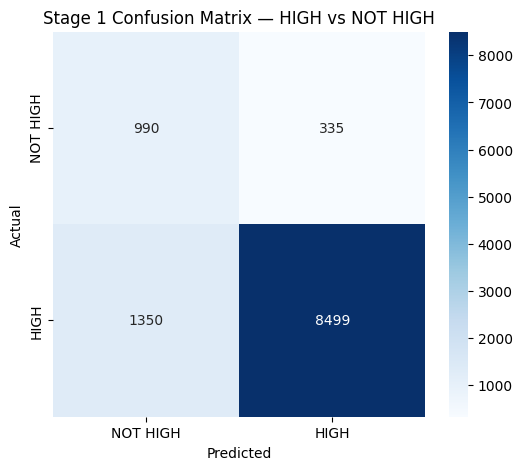

CV F1 Scores: [0.871 0.888 0.887 0.888 0.887]
Mean CV F1: 0.884 (+/- 0.013)


In [ ]:
y_pred1 = rf_stage1.predict(X_test1)

print("--- Stage 1: HIGH vs NOT HIGH ---")
print(classification_report(y_test1, y_pred1, target_names=['NOT HIGH', 'HIGH']))

kappa1 = cohen_kappa_score(y_test1, y_pred1)
print(f"Cohen's Kappa: {kappa1:.3f}")

# Confusion matrix
cm1 = confusion_matrix(y_test1, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NOT HIGH', 'HIGH'],
            yticklabels=['NOT HIGH', 'HIGH'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Stage 1 Confusion Matrix — HIGH vs NOT HIGH')
plt.show()

# CV score
cv1 = cross_val_score(rf_stage1, X_train1_bal, y_train1_bal, cv=5, scoring='f1')
print(f"CV F1 Scores: {cv1.round(3)}")
print(f"Mean CV F1: {cv1.mean():.3f} (+/- {cv1.std()*2:.3f})")

## Step 8 — Stage 1 Feature Importance

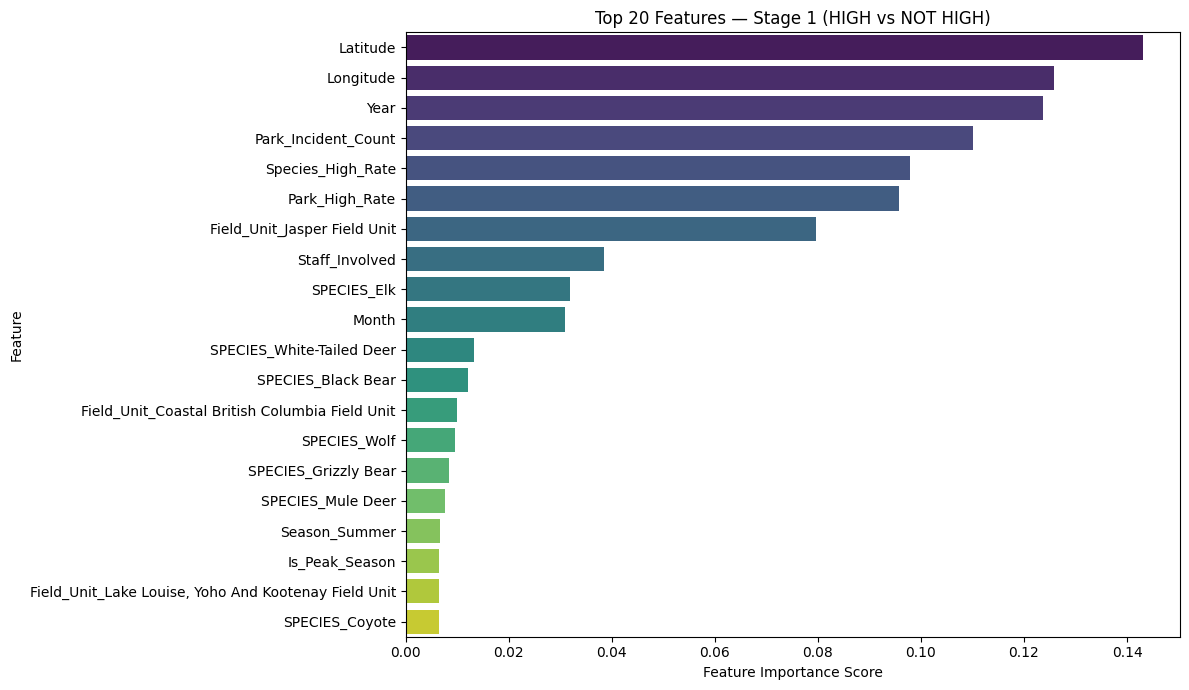

In [ ]:
importances1 = pd.Series(rf_stage1.feature_importances_, index=X.columns)
importances1 = importances1.sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 7))
sns.barplot(x=importances1.values, y=importances1.index,
            hue=importances1.index, palette='viridis', legend=False)
plt.title('Top 20 Features — Stage 1 (HIGH vs NOT HIGH)')
plt.xlabel('Feature Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## STAGE 2 ─ Sub-classification: LOW vs MEDIUM
Only runs on the subset of incidents that are NOT HIGH risk.
With HIGH removed, the LOW/MEDIUM boundary becomes learnable.

## Step 9 — Stage 2 Target and Split

In [ ]:
# Filter to only LOW and MEDIUM incidents
df_sub = df[df['RISK_LEVEL'] != 'HIGH'].copy()
X_sub  = X[df['RISK_LEVEL'] != 'HIGH'].copy()
y_sub  = (df_sub['RISK_LEVEL'] == 'MEDIUM').astype(int)  # 1=MEDIUM, 0=LOW

print("Stage 2 class distribution (LOW vs MEDIUM):")
print(y_sub.value_counts())

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)
print(f"\nTraining: {X_train2.shape[0]} | Test: {X_test2.shape[0]}")

Stage 2 class distribution (LOW vs MEDIUM):
RISK_LEVEL
0    5598
1    1028
Name: count, dtype: int64

Training: 5300 | Test: 1326


## Step 10 — Stage 2 SMOTE and Training

In [ ]:
print("Before SMOTE:", pd.Series(y_train2).value_counts().to_dict())

smote2 = SMOTE(sampling_strategy='minority', random_state=42)
X_train2_bal, y_train2_bal = smote2.fit_resample(X_train2, y_train2)

print("After SMOTE: ", pd.Series(y_train2_bal).value_counts().to_dict())

param_grid2 = {
    'n_estimators':      [100, 200],
    'max_depth':         [8, 12, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf':  [3, 5]
}

grid2 = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid2, cv=3, scoring='f1', n_jobs=-1
)
grid2.fit(X_train2_bal, y_train2_bal)

print("Best parameters:", grid2.best_params_)
rf_stage2 = grid2.best_estimator_

Before SMOTE: {0: 4478, 1: 822}
After SMOTE:  {0: 4478, 1: 4478}
Best parameters: {'max_depth': 15, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 200}


## Step 11 — Stage 2 Evaluation

--- Stage 2: LOW vs MEDIUM ---
              precision    recall  f1-score   support

         LOW       0.96      0.91      0.94      1120
      MEDIUM       0.62      0.80      0.70       206

    accuracy                           0.89      1326
   macro avg       0.79      0.86      0.82      1326
weighted avg       0.91      0.89      0.90      1326

Cohen's Kappa: 0.637


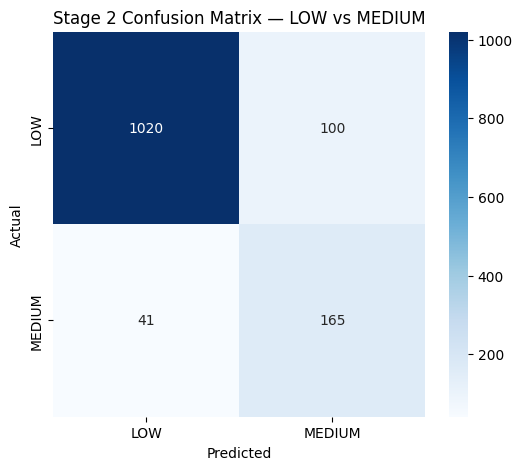

CV F1 Scores: [0.868 0.92  0.923 0.928 0.926]
Mean CV F1: 0.913 (+/- 0.046)


In [ ]:
y_pred2 = rf_stage2.predict(X_test2)

print("--- Stage 2: LOW vs MEDIUM ---")
print(classification_report(y_test2, y_pred2, target_names=['LOW', 'MEDIUM']))

kappa2 = cohen_kappa_score(y_test2, y_pred2)
print(f"Cohen's Kappa: {kappa2:.3f}")

cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW', 'MEDIUM'],
            yticklabels=['LOW', 'MEDIUM'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Stage 2 Confusion Matrix — LOW vs MEDIUM')
plt.show()

cv2 = cross_val_score(rf_stage2, X_train2_bal, y_train2_bal, cv=5, scoring='f1')
print(f"CV F1 Scores: {cv2.round(3)}")
print(f"Mean CV F1: {cv2.mean():.3f} (+/- {cv2.std()*2:.3f})")

## Step 12 — Combined Pipeline Evaluation
Run both stages together on the full test set to get the overall 3-class performance.

In [ ]:
# Recreate the full test split (same random_state=42 guarantees identical split)
y_3class = df['RISK_LEVEL'].map({'LOW': 0, 'MEDIUM': 1, 'HIGH': 2})
X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y_3class, test_size=0.2, random_state=42, stratify=y_3class
)

# Lower the Stage 1 threshold from 0.5 to 0.3
# Means: if the model is 30%+ confident something is HIGH, flag it as HIGH
# This reduces missed HIGH cases at the cost of some extra false alarms
STAGE1_THRESHOLD = 0.35

y_probs_stage1 = rf_stage1.predict_proba(X_test_full)
# predict_proba returns [prob_NOT_HIGH, prob_HIGH] — index 1 is HIGH probability
stage1_preds = (y_probs_stage1[:, 1] >= STAGE1_THRESHOLD).astype(int)

print(f"With threshold {STAGE1_THRESHOLD}:")
print(f"  Predicted HIGH: {stage1_preds.sum()}")
print(f"  Predicted NOT HIGH: {(stage1_preds == 0).sum()}")

# Stage 2 runs on everything Stage 1 said is NOT HIGH
final_preds = []
for i, is_high in enumerate(stage1_preds):
    if is_high == 1:
        final_preds.append(2)  # HIGH
    else:
        row = X_test_full.iloc[[i]]
        sub_pred = rf_stage2.predict(row)[0]
        final_preds.append(sub_pred)  # 0=LOW, 1=MEDIUM

final_preds = np.array(final_preds)

print("\n--- Combined Pipeline (Threshold = 0.3) ---")
print(classification_report(
    y_test_full, final_preds,
    target_names=['LOW', 'MEDIUM', 'HIGH']
))

kappa_combined = cohen_kappa_score(y_test_full, final_preds)
print(f"Combined Cohen's Kappa: {kappa_combined:.3f}")

# Show how many HIGH cases are now missed
missed_high = ((y_test_full == 2) & (final_preds != 2)).sum()
caught_high = ((y_test_full == 2) & (final_preds == 2)).sum()
print(f"\nHIGH Risk — Caught: {caught_high} | Missed: {missed_high}")

With threshold 0.35:
  Predicted HIGH: 9522
  Predicted NOT HIGH: 1652

--- Combined Pipeline (Threshold = 0.3) ---
              precision    recall  f1-score   support

         LOW       0.55      0.65      0.60      1120
      MEDIUM       0.41      0.67      0.51       205
        HIGH       0.96      0.93      0.95      9849

    accuracy                           0.90     11174
   macro avg       0.64      0.75      0.68     11174
weighted avg       0.91      0.90      0.90     11174

Combined Cohen's Kappa: 0.566

HIGH Risk — Caught: 9159 | Missed: 690


In [ ]:
# Try a range of thresholds and find which one minimises HIGH misses
# while keeping overall Kappa acceptable
thresholds = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print(f"{'Threshold':<12} {'HIGH Missed':<14} {'HIGH Caught':<14} {'Kappa':<8} {'HIGH Recall'}")
print("-" * 65)

for thresh in thresholds:
    preds_stage1 = (y_probs_stage1[:, 1] >= thresh).astype(int)

    preds_final = []
    for i, is_high in enumerate(preds_stage1):
        if is_high == 1:
            preds_final.append(2)
        else:
            row = X_test_full.iloc[[i]]
            preds_final.append(rf_stage2.predict(row)[0])

    preds_final = np.array(preds_final)
    kappa = cohen_kappa_score(y_test_full, preds_final)
    missed = ((y_test_full == 2) & (preds_final != 2)).sum()
    caught = ((y_test_full == 2) & (preds_final == 2)).sum()
    recall_high = caught / (caught + missed)

    print(f"{thresh:<12} {missed:<14} {caught:<14} {kappa:<8.3f} {recall_high:.3f}")

Threshold    HIGH Missed    HIGH Caught    Kappa    HIGH Recall
-----------------------------------------------------------------
0.15         165            9684           0.462    0.983
0.2          291            9558           0.521    0.970
0.25         408            9441           0.541    0.959
0.3          530            9319           0.556    0.946
0.35         690            9159           0.566    0.930
0.4          865            8984           0.556    0.912
0.45         1060           8789           0.542    0.892
0.5          1338           8511           0.506    0.864


## Step 13 — Combined Confusion Matrix

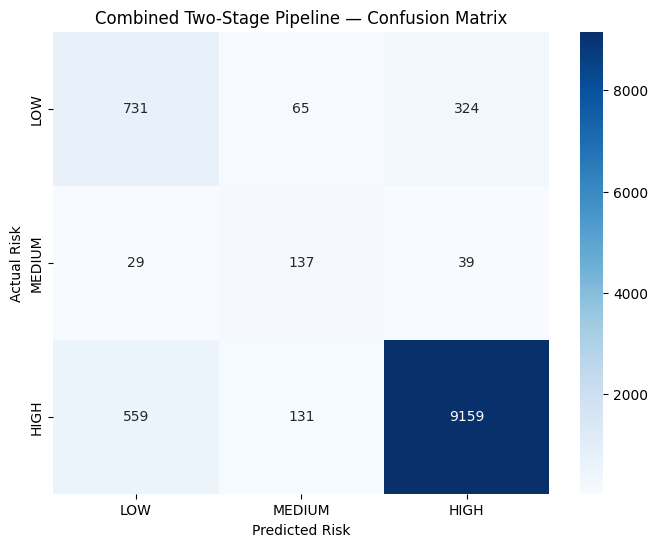

In [ ]:
cm_combined = confusion_matrix(y_test_full, final_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=['LOW', 'MEDIUM', 'HIGH'],
            yticklabels=['LOW', 'MEDIUM', 'HIGH'])
plt.ylabel('Actual Risk')
plt.xlabel('Predicted Risk')
plt.title('Combined Two-Stage Pipeline — Confusion Matrix')
plt.show()

## Step 14 — Prediction Error Maps
Three geographic plots showing where predictions are correct, wrong,
and specifically where HIGH risk incidents were missed.

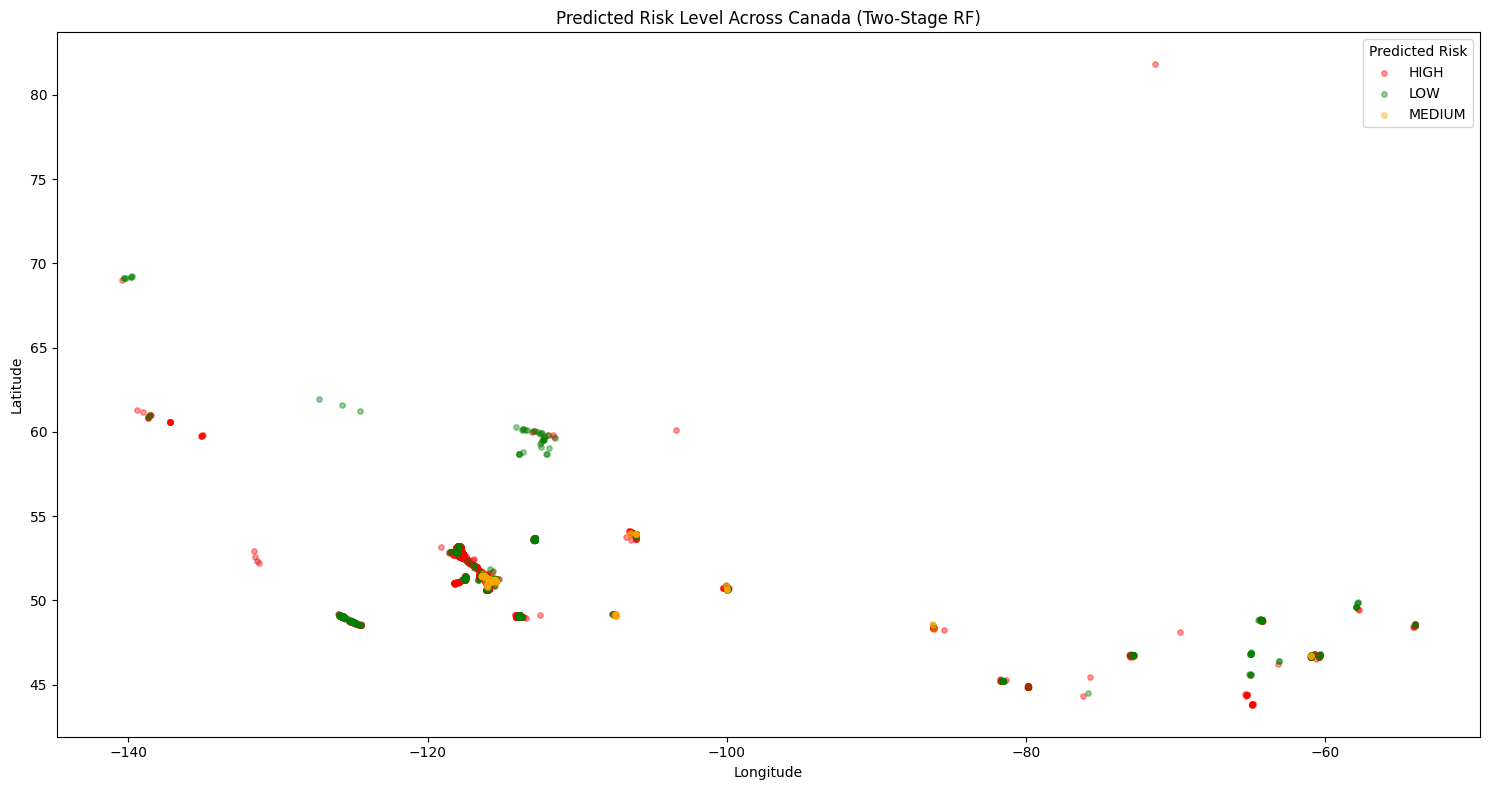

In [ ]:
df_test_plot = X_test_full[['Latitude', 'Longitude']].copy()
df_test_plot['Actual']    = y_test_full.values
df_test_plot['Predicted'] = final_preds

reverse_map = {0: 'LOW', 1: 'MEDIUM', 2: 'HIGH'}
df_test_plot['Predicted_Label'] = df_test_plot['Predicted'].map(reverse_map)
df_test_plot['Actual_Label']    = df_test_plot['Actual'].map(reverse_map)

# --- Plot 1: What the model predicted across Canada ---
plt.figure(figsize=(15, 8))
colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'green'}
for risk, grp in df_test_plot.groupby('Predicted_Label'):
    plt.scatter(grp['Longitude'], grp['Latitude'],
                c=colors[risk], label=risk, alpha=0.4, s=15)
plt.title('Predicted Risk Level Across Canada (Two-Stage RF)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Predicted Risk')
plt.tight_layout()
plt.show()

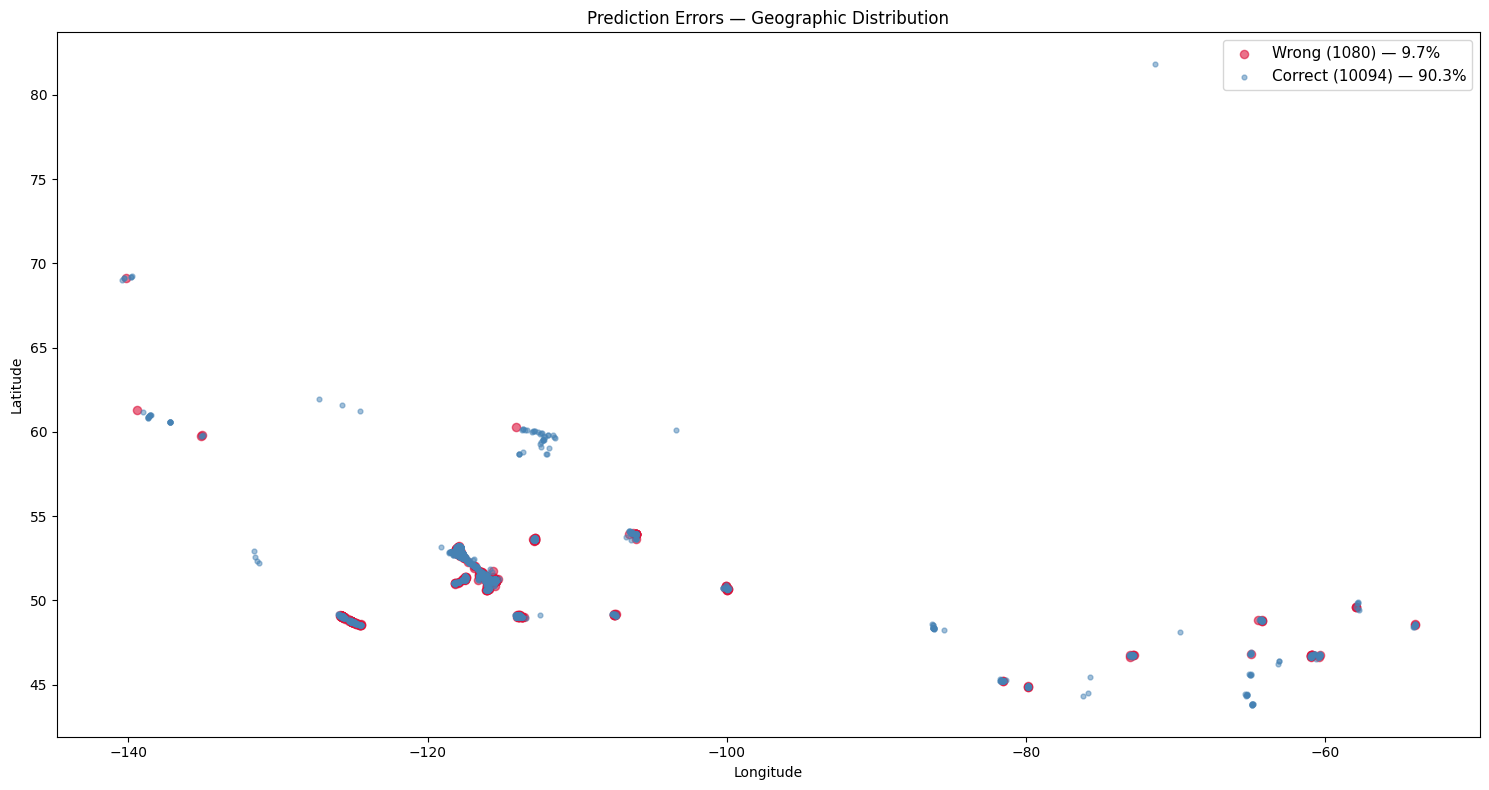

In [ ]:
# --- Plot 2: Correct vs wrong predictions ---
# Plot wrong ones FIRST (underneath), correct ones on top
# Size difference reinforces which group is larger
plt.figure(figsize=(15, 8))
plt.scatter(df_wrong['Longitude'], df_wrong['Latitude'],
            c='crimson', alpha=0.6, s=35,
            label=f'Wrong ({len(df_wrong)}) — {len(df_wrong)/len(df_test_plot)*100:.1f}%',
            zorder=1)
plt.scatter(df_right['Longitude'], df_right['Latitude'],
            c='steelblue', alpha=0.5, s=12,
            label=f'Correct ({len(df_right)}) — {len(df_right)/len(df_test_plot)*100:.1f}%',
            zorder=2)  # zorder=2 draws correct predictions on top
plt.title('Prediction Errors — Geographic Distribution')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

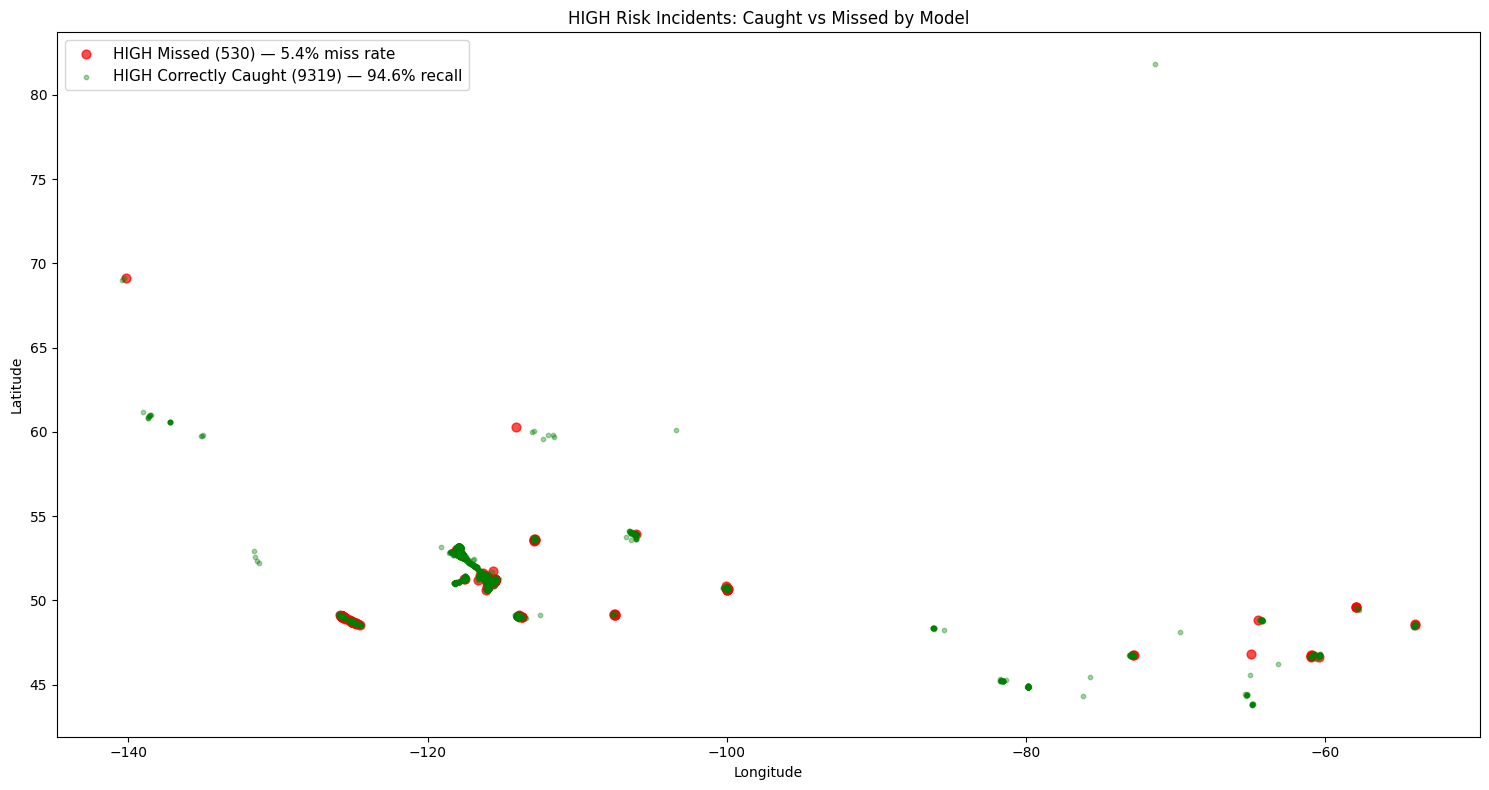

In [ ]:
# --- Plot 3: HIGH risk misses ---
# Same fix — missed ones underneath, caught ones on top
plt.figure(figsize=(15, 8))
plt.scatter(df_missed_high['Longitude'], df_missed_high['Latitude'],
            c='red', alpha=0.7, s=40,
            label=f'HIGH Missed ({len(df_missed_high)}) — {len(df_missed_high)/len(df_caught_high+df_missed_high)*100:.1f}% miss rate',
            zorder=1)
plt.scatter(df_caught_high['Longitude'], df_caught_high['Latitude'],
            c='green', alpha=0.35, s=10,
            label=f'HIGH Correctly Caught ({len(df_caught_high)}) — {len(df_caught_high)/(len(df_caught_high)+len(df_missed_high))*100:.1f}% recall',
            zorder=2)
plt.title('HIGH Risk Incidents: Caught vs Missed by Model')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

## Saving the Files

### For Backend

In [ ]:
import joblib

# Save both stage models — backend needs both to run the full pipeline
joblib.dump(rf_stage1, '/content/drive/MyDrive/parks_canada_rf_stage1.joblib')
joblib.dump(rf_stage2, '/content/drive/MyDrive/parks_canada_rf_stage2.joblib')

# Save the feature column names — critical for backend to send data in correct format
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, '/content/drive/MyDrive/parks_canada_rf_features.joblib')

print("Saved:")
print("  parks_canada_rf_stage1.joblib  — HIGH vs NOT HIGH classifier")
print("  parks_canada_rf_stage2.joblib  — LOW vs MEDIUM classifier")
print("  parks_canada_rf_features.joblib — feature column names")

Saved:
  parks_canada_rf_stage1.joblib  — HIGH vs NOT HIGH classifier
  parks_canada_rf_stage2.joblib  — LOW vs MEDIUM classifier
  parks_canada_rf_features.joblib — feature column names


### For Frontend

In [ ]:
import numpy as np

# Build prediction grid across Canada
# 150x150 gives good resolution without being too slow
grid_res = 150
lats = np.linspace(42, 84, grid_res)
lons = np.linspace(-141, -52, grid_res)
grid_lon, grid_lat = np.meshgrid(lons, lats)

flat_lat = grid_lat.flatten()
flat_lon = grid_lon.flatten()

# Build grid dataframe with same columns as training data
grid_df = pd.DataFrame(0, index=range(len(flat_lat)), columns=X.columns)
grid_df['Latitude']           = flat_lat
grid_df['Longitude']          = flat_lon
grid_df['Month']              = 7       # July — peak conflict month
grid_df['Year']               = 2023    # most recent year
grid_df['Is_Peak_Season']     = 1
grid_df['In_Park_Binary']     = 1
grid_df['Staff_Involved']     = df['Staff_Involved'].mean()
grid_df['Park_Incident_Count']= df['Park_Incident_Count'].mean()
grid_df['Park_High_Rate']     = df['Park_High_Rate'].mean()
grid_df['Species_High_Rate']  = df['Species_High_Rate'].mean()

# Get HIGH risk probability from Stage 1
high_probs = rf_stage1.predict_proba(grid_df)[:, 1]

# Apply threshold to get predicted class
stage1_labels = (high_probs >= 0.35).astype(int)

# Run Stage 2 on NOT HIGH predictions
final_labels = []
for i, is_high in enumerate(stage1_labels):
    if is_high == 1:
        final_labels.append('HIGH')
    else:
        row = grid_df.iloc[[i]]
        sub = rf_stage2.predict(row)[0]
        final_labels.append('MEDIUM' if sub == 1 else 'LOW')

# Build results dataframe
results_df = pd.DataFrame({
    'Latitude':       flat_lat,
    'Longitude':      flat_lon,
    'Risk_Level':     final_labels,
    'High_Risk_Prob': high_probs.round(4)
})

# Save to CSV for frontend use
results_df.to_csv(
    '/content/drive/MyDrive/parks_canada_risk_grid.csv',
    index=False
)

print(f"Risk grid saved: {results_df.shape[0]} coordinate points")
print(results_df['Risk_Level'].value_counts())
print(results_df.head(10))

Risk grid saved: 22500 coordinate points
Risk_Level
HIGH    22500
Name: count, dtype: int64
   Latitude   Longitude Risk_Level  High_Risk_Prob
0      42.0 -141.000000       HIGH          0.6598
1      42.0 -140.402685       HIGH          0.6598
2      42.0 -139.805369       HIGH          0.6598
3      42.0 -139.208054       HIGH          0.6598
4      42.0 -138.610738       HIGH          0.6631
5      42.0 -138.013423       HIGH          0.6590
6      42.0 -137.416107       HIGH          0.6590
7      42.0 -136.818792       HIGH          0.6590
8      42.0 -136.221477       HIGH          0.6590
9      42.0 -135.624161       HIGH          0.6590
